In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load the data
file_path = r'd:\FakeD\.HOMEWORK\KMUTT\Year4\Senior_project\github\Framework_Simulation_Garbage\Causal_extractor\data_extract\output\response_v4_9.json'

with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)

print(f"Total records: {len(df)}")
print(f"\nPattern type distribution:")
print(df['pattern_type'].value_counts())

Total records: 18

Pattern type distribution:
pattern_type
C    12
F     4
A     2
Name: count, dtype: int64


In [3]:
# Filter for Causal pattern type ("C")
causal_df = df[df['pattern_type'] == 'C'].copy()

print(f"Total Causal (C) pattern records: {len(causal_df)}")
print(f"\nFirst few causal relationships:")
print(causal_df[['subject', 'relationship', 'object']].head(10))

Total Causal (C) pattern records: 12

First few causal relationships:
                                   subject  \
1                               Some event   
2               An unusual amount of trash   
3          limited space in our university   
4             Garbage buffer storing trash   
5        Universities accept more students   
6       Increase in the number of students   
7                The most important factor   
8   gains after employing developed policy   
9   gains after employing developed policy   
13                  Management (ผู้บริหาร)   

                                         relationship  \
1     Some event -> Causes an unusual amount of trash   
2   An unusual amount of trash -> University staff...   
3   Limited space in university -> Garbage buffer ...   
4   Storing trash in a buffer -> Prevents normal c...   
5   Universities accept more students -> Challenge...   
6   Increase in the number of students -> Increase...   
7   The most important f

In [4]:
# Extract the activity/action from the relationship field
# The relationship field format is: "Subject -> Activity/Action"
def extract_activity(relationship_str):
    """Extract the activity/action between subject and object"""
    if '->' in relationship_str:
        parts = relationship_str.split('->')
        if len(parts) >= 2:
            # The activity is typically in the second part or describes the connection
            activity = parts[1].strip()
            return activity
    return relationship_str

causal_df['activity'] = causal_df['relationship'].apply(extract_activity)

# Display subject-activity-object relationships
print("Subject -> Activity -> Object relationships:\n")
for idx, row in causal_df.iterrows():
    print(f"Subject: {row['subject']}")
    print(f"Activity: {row['activity']}")
    print(f"Object: {row['object']}")
    print(f"Full relationship: {row['relationship']}")
    print(f"Marker: {row['marker']}")
    print("-" * 80)

Subject -> Activity -> Object relationships:

Subject: Some event
Activity: Causes an unusual amount of trash
Object: An unusual amount of trash
Full relationship: Some event -> Causes an unusual amount of trash
Marker: causes
--------------------------------------------------------------------------------
Subject: An unusual amount of trash
Activity: University staff call for trash trucks
Object: University staff call for trash trucks
Full relationship: An unusual amount of trash -> University staff call for trash trucks
Marker: None
--------------------------------------------------------------------------------
Subject: limited space in our university
Activity: Garbage buffer is created
Object: the garbage buffer
Full relationship: Limited space in university -> Garbage buffer is created
Marker: due to
--------------------------------------------------------------------------------
Subject: Garbage buffer storing trash
Activity: Prevents normal collection points from overflowing
Obj

In [5]:
# Analyze the most common activities/relationships
activity_counts = Counter(causal_df['activity'].tolist())

print(f"\nMost common activities in causal relationships (Top 15):")
print("-" * 80)
for activity, count in activity_counts.most_common(15):
    print(f"{count:3d}x | {activity}")


Most common activities in causal relationships (Top 15):
--------------------------------------------------------------------------------
  1x | Causes an unusual amount of trash
  1x | University staff call for trash trucks
  1x | Garbage buffer is created
  1x | Prevents normal collection points from overflowing
  1x | Challenges emerge
  1x | Increases the number of trash producers
  1x | Makes the project fail
  1x | Consume more monthly cost
  1x | Give insignificant improvement
  1x | Policy changes
  1x | Garbage appears to overflow
  1x | Inaccurate weight measurements


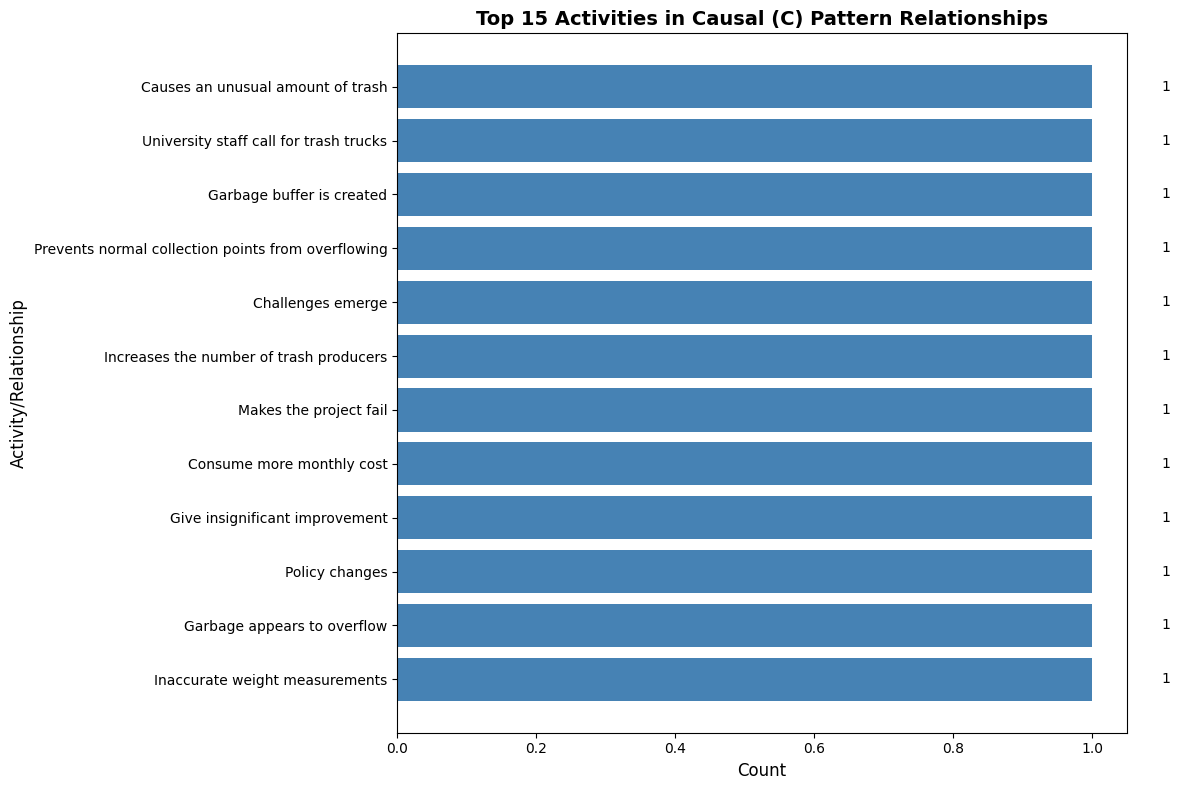

In [6]:
# Visualize the distribution of activities
fig, ax = plt.subplots(figsize=(12, 8))

# Get top 15 activities
top_activities = dict(activity_counts.most_common(15))
activities_list = list(top_activities.keys())
counts_list = list(top_activities.values())

ax.barh(activities_list, counts_list, color='steelblue')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Activity/Relationship', fontsize=12)
ax.set_title('Top 15 Activities in Causal (C) Pattern Relationships', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels on bars
for i, (activity, count) in enumerate(zip(activities_list, counts_list)):
    ax.text(count + 0.1, i, str(count), va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
# Create a detailed DataFrame showing the relationships
relationship_df = causal_df[['subject', 'activity', 'object', 'marker', 'marked_type', 'source_text']].copy()

# Save to CSV for further analysis
output_path = r'd:\FakeD\.HOMEWORK\KMUTT\Year4\Senior_project\github\Framework_Simulation_Garbage\Simulation\data\entity\causal_relationships.csv'
relationship_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Causal relationships saved to: {output_path}")
print(f"\nTotal causal relationships: {len(relationship_df)}")
print(f"\nRelationship breakdown:")
print(relationship_df.head(20).to_string())

Causal relationships saved to: d:\FakeD\.HOMEWORK\KMUTT\Year4\Senior_project\github\Framework_Simulation_Garbage\Simulation\data\entity\causal_relationships.csv

Total causal relationships: 12

Relationship breakdown:
                                           subject                                            activity                                                        object     marker marked_type                                                                                                                                      source_text
1                                       Some event                   Causes an unusual amount of trash                                    An unusual amount of trash     causes           M                                university staff will call for trash trucks only when there is some event that causes an unusual amount of trash.
2                       An unusual amount of trash              University staff call for trash trucks              

In [8]:
# Analyze marker usage in causal relationships
print("Marker Analysis for Causal Patterns:")
print("=" * 80)
print(f"\nMarked vs Unmarked:")
print(causal_df['marked_type'].value_counts())

print(f"\n\nMarkers used (when marked):")
marked_causal = causal_df[causal_df['marked_type'] == 'M']
print(marked_causal['marker'].value_counts())

print(f"\n\nExamples of marked causal relationships:")
for idx, row in marked_causal.head(10).iterrows():
    print(f"\nMarker: '{row['marker']}'")
    print(f"Subject: {row['subject']}")
    print(f"Object: {row['object']}")
    print(f"Activity: {row['activity']}")
    print(f"Source: {row['source_text'][:100]}...")

Marker Analysis for Causal Patterns:

Marked vs Unmarked:
marked_type
U    9
M    3
Name: count, dtype: int64


Markers used (when marked):
marker
causes       1
due to       1
เนื่องจาก    1
Name: count, dtype: int64


Examples of marked causal relationships:

Marker: 'causes'
Subject: Some event
Object: An unusual amount of trash
Activity: Causes an unusual amount of trash
Source: university staff will call for trash trucks only when there is some event that causes an unusual amo...

Marker: 'due to'
Subject: limited space in our university
Object: the garbage buffer
Activity: Garbage buffer is created
Source: Also due to limited space in our university, the garbage buffer is created to store trash preventing...

Marker: 'เนื่องจาก'
Subject: Personnel (บุคลากร)
Object: Inaccurate weight measurements (การคาดเคลื่อนการชั่งน้ำหนัก)
Activity: Inaccurate weight measurements
Source: ปัญหา 1 -> การคาดเคลื่อนการชั่งน้ำหนักเนื่องจากบุคลากร...


In [9]:
# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY OF CAUSAL RELATIONSHIPS")
print("=" * 80)

print(f"\nTotal Causal (C) patterns: {len(causal_df)}")
print(f"Unique subjects: {causal_df['subject'].nunique()}")
print(f"Unique objects: {causal_df['object'].nunique()}")
print(f"Unique activities: {len(activity_counts)}")

print(f"\n\nSentence Type Distribution:")
print(causal_df['sentence_type'].value_counts())

print(f"\n\nExplicit vs Implicit:")
print(causal_df['explicit_type'].value_counts())

print(f"\n\nKey Insights:")
print(f"- Most common activity: '{activity_counts.most_common(1)[0][0]}' ({activity_counts.most_common(1)[0][1]} occurrences)")
print(f"- Marked relationships: {len(causal_df[causal_df['marked_type'] == 'M'])} ({len(causal_df[causal_df['marked_type'] == 'M'])/len(causal_df)*100:.1f}%)")
print(f"- Unmarked relationships: {len(causal_df[causal_df['marked_type'] == 'U'])} ({len(causal_df[causal_df['marked_type'] == 'U'])/len(causal_df)*100:.1f}%)")


SUMMARY OF CAUSAL RELATIONSHIPS

Total Causal (C) patterns: 12
Unique subjects: 11
Unique objects: 12
Unique activities: 12


Sentence Type Distribution:
sentence_type
SB    5
ES    3
OT    3
SP    1
Name: count, dtype: int64


Explicit vs Implicit:
explicit_type
E    9
I    3
Name: count, dtype: int64


Key Insights:
- Most common activity: 'Causes an unusual amount of trash' (1 occurrences)
- Marked relationships: 3 (25.0%)
- Unmarked relationships: 9 (75.0%)
